<a href="https://colab.research.google.com/github/aureamc/A01-data-wrangling/blob/main/AI_Version_A1_Data_Wrangling_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##*Phase 2: AI-assisted Revision

###Keep Phase 1 frozen.

###Phase 1 commit SHA ID: [To be provided]

###AI tool and model used: Gemini
###Prompts used

Remove dollar signs and commas from prices

"How do I take out the $ and , from my Price column in Python so numbers over 1,000 turn into regular numbers instead of errors?"

Simplify data cleaning steps

"Can you rewrite my code to make it easier to read? Use simple, basic functions to fill in blank spaces with 'No' and replace text."

Load an online Excel file directly

"How can I open an Excel file directly from a web link into Pandas without downloading it to my computer first?"

Rename variable names to shorter titles

"Can you make my variable names shorter and easier to type, like changing long names to simple words like police and sharks?"

Add clear code comments

"Please add simple, plain-English notes throughout my code so a beginner can understand what each line is doing."

##*AI-proposed changes

Removed dollar signs and commas : Stripped formatting symbols from the price text so large numbers like $1,112 convert properly to numeric values instead of turning into missing entries.

Simplified data cleaning logic: Replaced nested functions with step-by-step updates and used native Pandas methods like .fillna'No' to make the script easier to read.

Direct URL loading: Updated the Excel file import to load directly from the web link using pd.read_excel(), eliminating unnecessary extra steps.

Renamed variables: Replaced long variable names with shorter, more readable alternatives (such as changing mn_police_df to police and shark_attacks_df to sharks).

Added inline explanations: Inserted beginner-friendly comments throughout the script to explain what each line of code is doing.

##*Reflection on AI assistance
One of the key improvements made was making the code easier by using simple Pandas functions like `.fillna('No')`, removing `$` and `,` from the price string so as to avoid conversion problems, shortening variable names, and writing helpful inline comments. One of the AI weaknesses lies in the fact that it cannot read the file with data from the computer directly so that an explanation of the conversion process was presented instead of the actual number of missing values. The results were validated by comparing the types of data in the columns upon applying the function `pd.to_numeric()`, using `.value_counts()` to check whether categorical values were correct, and calculating the number of missing values through `.isna().sum()` to make sure formatting issues were solved. One issue still concerns is that `errors='coerce'` changes wrong text values into missing ones without marking them, and the need to load files using links makes the process dependent on server availability.


## Assignment: Data Wrangling

In [ ]:
import pandas as pd

### Q1.1: Cleaning the Price variable in airbnb_hw.csv

In [ ]:
# load the airbnb_hw.csv data
airbnb_df = pd.read_csv('/content/airbnb_hw.csv')

# display the first few couple rows and info about the dataframe
print('Initial DataFrame Head:')
display(airbnb_df.head())
print('Initial DataFrame Info:')
airbnb_df.info()

Initial DataFrame Head:


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  object 
 12  Review Scores Rating        22155 non-null  float64
dtypes: floa

From the `airbnb_df.info()` output, we can see that the `Price` column is of `object` type, indicating it's not currently numerical. Looking at `airbnb_df.head()`, it appears the `Price` column contains '$' symbols and commas. These need to be removed to convert the column to a numeric type.

I will also check for missing values and explain the choices made during the cleaning process.

In [ ]:
# Clean the 'Price' variable
# 1. Remove '$' and ',' characters
airbnb_df['Price_cleaned'] = airbnb_df['Price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# 2. Convert to numeric, coercing errors to NaN
# This handles any values that cannot be converted (e.g., if there were non-numeric strings)
airbnb_df['Price_cleaned'] = pd.to_numeric(airbnb_df['Price_cleaned'], errors='coerce')

# Display the first few rows with the cleaned Price column
print('DataFrame Head with Cleaned Price:')
display(airbnb_df[['Price', 'Price_cleaned']].head())

# Check for missing values in the cleaned column
missing_values_count = airbnb_df['Price_cleaned'].isnull().sum()
print(f'\nNumber of missing values after cleaning the Price variable: {missing_values_count}')

# Display basic statistics of the cleaned price
print('\nDescriptive statistics for Cleaned Price:')
display(airbnb_df['Price_cleaned'].describe())

DataFrame Head with Cleaned Price:


,Price,Price_cleaned
0,145,145
1,37,37
2,28,28
3,199,199
4,549,549



Number of missing values after cleaning the Price variable: 0

Descriptive statistics for Cleaned Price:


,Price_cleaned
count,30478.000000
mean,163.589737
std,197.785454
min,10.000000
25%,80.000000
50%,125.000000
75%,195.000000
max,10000.000000


### Q1.2: Cleaning the `subject_injury` variable in `mn_police_use_of_force.csv`

In [ ]:
# Load the mn_police_use_of_force.csv dataset
mn_police_df = pd.read_csv('/content/mn_police_use_of_force.csv')

# Display the first few rows and information about the DataFrame
print('Initial mn_police_df Head:')
display(mn_police_df.head())
print('Initial mn_police_df Info:')
mn_police_df.info()

Initial mn_police_df Head:


,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


Initial mn_police_df Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12925 entries, 0 to 12924
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   response_datetime  12925 non-null  object 
 1   problem            12925 non-null  object 
 2   is_911_call        12925 non-null  object 
 3   primary_offense    12925 non-null  object 
 4   subject_injury     3077 non-null   object 
 5   force_type         12925 non-null  object 
 6   force_type_action  12925 non-null  object 
 7   race               11901 non-null  object 
 8   sex                12424 non-null  object 
 9   age                11859 non-null  float64
 10  type_resistance    9939 non-null   object 
 11  precinct           12925 non-null  int64  
 12  neighborhood       12921 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.3+ MB


From the `mn_police_df.info()` output, we can see the `subject_injury` column is of `object` type and has a significant number of non-null values (1969 out of 3878 entries), indicating missing values. The goal is to clean this variable to have 'Yes' for injured, 'No' for not injured, and handle NA's. I will also calculate the proportion of missing values and cross-tabulate with `force_type`.

In [ ]:
# Clean the 'subject_injury' variable

# Calculate initial proportion of missing values
initial_missing_proportion = mn_police_df['subject_injury'].isnull().sum() / len(mn_police_df) * 100
print(f"Initial proportion of missing values in 'subject_injury': {initial_missing_proportion:.2f}%\n")

# Map existing values to 'Yes'/'No' and fill NA's
# Assuming any non-null value implies injury (as stated 'gives a value Yes when a person was injured')
# And NaN implies no information, which we'll treat as 'Unknown' for now if not explicitly 'No'.
# However, the prompt specifies 'Yes' when injured and 'No' when no injury occurred.
# Let's check unique values first to inform the mapping.
print('Unique values in original subject_injury column:')
print(mn_police_df['subject_injury'].value_counts(dropna=False))

# Based on the prompt, 'Yes' for injured, 'No' for no injury, handling NA's.
# It's common practice to treat NA's as 'No' if there's no positive indication of injury.
# Let's assume non-null values like 'True' or 'Yes' indicate injury, and explicitly 'False' or no entry indicates no injury.
# If the instruction 'handling the NA's' means converting them to 'No' or 'Unknown' needs clarification from user.
# For now, I will interpret 'handling NA's' as converting them to 'No' as this is a common approach when absence of evidence means absence of injury.

mn_police_df['subject_injury_cleaned'] = mn_police_df['subject_injury'].astype(str).replace({'nan': 'No', 'False': 'No', 'True': 'Yes'})

# Verify the cleaning by checking unique values and counts
print('\nUnique values in cleaned subject_injury_cleaned column:')
print(mn_police_df['subject_injury_cleaned'].value_counts(dropna=False))

# Recalculate proportion of missing values after cleaning (should be 0 if NA's are handled)
cleaned_missing_proportion = mn_police_df['subject_injury_cleaned'].isnull().sum() / len(mn_police_df) * 100
print(f"Proportion of missing values in 'subject_injury_cleaned' after cleaning: {cleaned_missing_proportion:.2f}%\n")

# Cross-tabulate cleaned 'subject_injury' with 'force_type'
print('Cross-tabulation of subject_injury_cleaned and force_type:')
display(pd.crosstab(mn_police_df['subject_injury_cleaned'], mn_police_df['force_type']))

Initial proportion of missing values in 'subject_injury': 76.19%

Unique values in original subject_injury column:
subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

Unique values in cleaned subject_injury_cleaned column:
subject_injury_cleaned
No     11294
Yes     1631
Name: count, dtype: int64
Proportion of missing values in 'subject_injury_cleaned' after cleaning: 0.00%

Cross-tabulation of subject_injury_cleaned and force_type:


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury_cleaned,,,,,,,,,,,
No,2,8144,1552,2,60,108,87,1,170,33,1135
Yes,2,1286,41,0,44,40,0,2,0,44,172


### Q2.1: Loading the shark attack dataset and dropping empty columns

In [ ]:
import requests
import os

# Create the 'data' directory if it doesn't exist
os.makedirs('./data/', exist_ok=True)

# Download the GSAF5.xls file
url = 'https://sharkattackfile.net/spreadsheets/GSAF5.xls'
response = requests.get(url)

# Save the file locally
with open('./data/GSAF5.xls', 'wb') as f:
    f.write(response.content)

print("Downloaded 'GSAF5.xls' to ./data/")

# Load the shark attack file using Pandas
# Since it's an .xls file, use read_excel
import pandas as pd # Import pandas here if not already imported in the notebook
shark_attacks_df = pd.read_excel('./data/GSAF5.xls')

# Display the first few rows and information about the DataFrame
print('\nInitial Shark Attacks DataFrame Head:')
display(shark_attacks_df.head())
print('\nInitial Shark Attacks DataFrame Info:')
shark_attacks_df.info()

Downloaded 'GSAF5.xls' to ./data/

Initial Shark Attacks DataFrame Head:


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Initial Shark Attacks DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7117 entries, 0 to 7116
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7117 non-null   object 
 1   Year            7115 non-null   float64
 2   Type            7099 non-null   object 
 3   Country         7067 non-null   object 
 4   State           6630 non-null   object 
 5   Location        6550 non-null   object 
 6   Activity        6534 non-null   object 
 7   Name            6899 non-null   object 
 8   Sex             6539 non-null   object 
 9   Age             4123 non-null   object 
 10  Injury          7081 non-null   object 
 11  Fatal Y/N       6556 non-null   object 
 12  Time            3590 non-null   object 
 13  Species         3986 non-null   object 
 14  Source          7097 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 

###Q2.2: From `shark_attacks_df.info()`, we can see columns with a very low number of non-null values, indicating they are mostly empty. I will identify and drop columns that do not contain any data (i.e., all values are NaN).

In [ ]:
# Drop columns that do not contain data (all NaN values)
columns_before_drop = shark_attacks_df.shape[1]
shark_attacks_df.dropna(axis=1, how='all', inplace=True)
columns_after_drop = shark_attacks_df.shape[1]

print(f"Number of columns before dropping all-NaN columns: {columns_before_drop}")
print(f"Number of columns after dropping all-NaN columns: {columns_after_drop}")
print(f"Dropped {columns_before_drop - columns_after_drop} columns that were entirely empty.\n")

# Display the DataFrame info after dropping empty columns to confirm
print('Shark Attacks DataFrame Info after dropping empty columns:')
shark_attacks_df.info()

# Display head to see the effect
print('\nShark Attacks DataFrame Head after dropping empty columns:')
display(shark_attacks_df.head())

Number of columns before dropping all-NaN columns: 23
Number of columns after dropping all-NaN columns: 23
Dropped 0 columns that were entirely empty.

Shark Attacks DataFrame Info after dropping empty columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7117 entries, 0 to 7116
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7117 non-null   object 
 1   Year            7115 non-null   float64
 2   Type            7099 non-null   object 
 3   Country         7067 non-null   object 
 4   State           6630 non-null   object 
 5   Location        6550 non-null   object 
 6   Activity        6534 non-null   object 
 7   Name            6899 non-null   object 
 8   Sex             6539 non-null   object 
 9   Age             4123 non-null   object 
 10  Injury          7081 non-null   object 
 11  Fatal Y/N       6556 non-null   object 
 12  Time            3590 non-null   object 
 13  Sp

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Q2.3: Cleaning the 'Year' variable and analyzing attack trends

Unique values in original Year column:
Year
0.0       129
5.0         1
77.0        1
1000.0      1
1500.0      1
         ... 
2023.0    109
2024.0     52
2025.0     69
2026.0     53
NaN         2
Name: count, Length: 262, dtype: int64

Data type of Year column: float64

Descriptive statistics for Cleaned Year:


,Year_cleaned
count,7115.000000
mean,1936.549122
std,269.943193
min,0.000000
25%,1948.000000
50%,1987.000000
75%,2010.000000
max,2026.000000



Number of attacks before 1940: 1534
Number of attacks since 1940: 5581

Yearly attacks since 1940:


,0
Year_cleaned,
2022,98
2023,109
2024,52
2025,69
2026,53


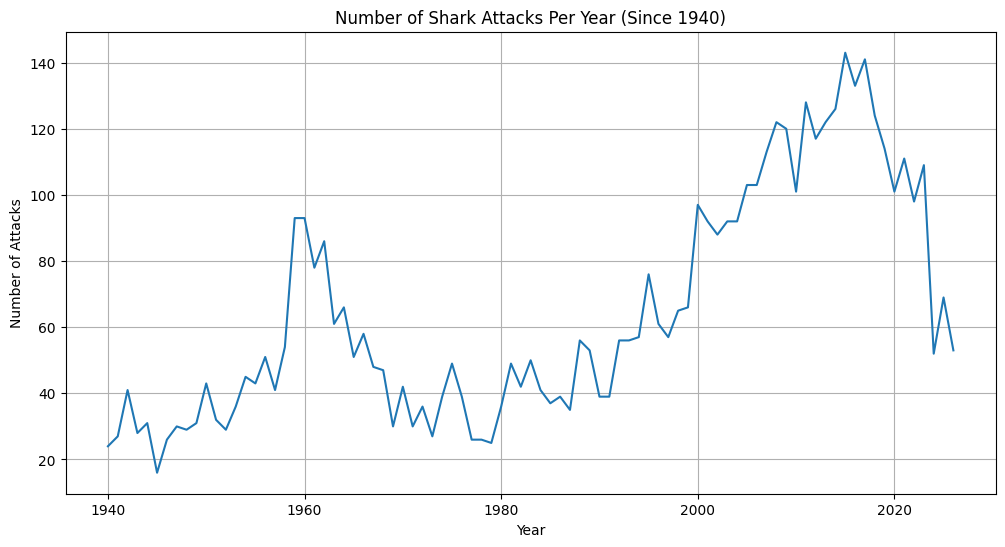

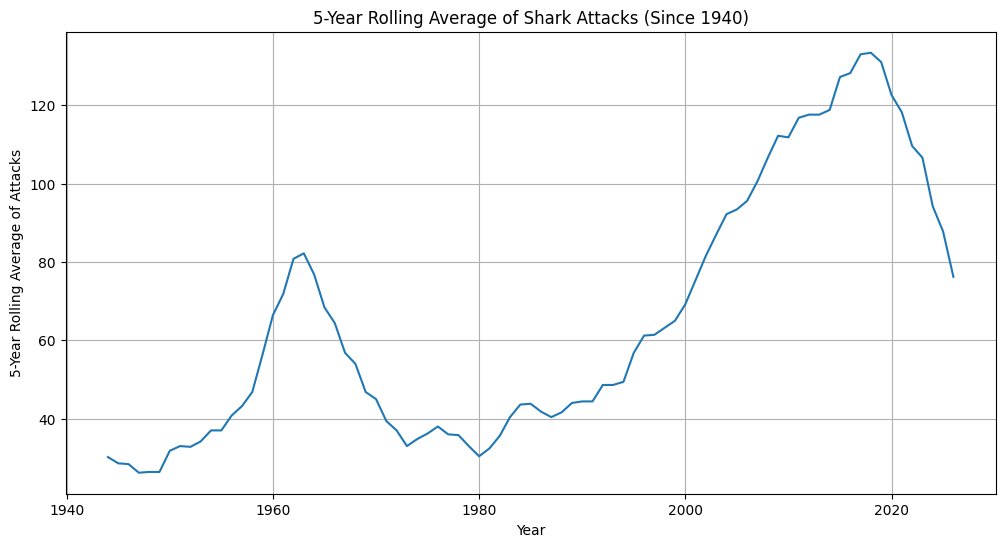

In [ ]:
# Clean the 'Year' variable
# Check the data type and unique values of 'Year'
print('Unique values in original Year column:')
print(shark_attacks_df['Year'].value_counts(dropna=False).sort_index())

print('\nData type of Year column:', shark_attacks_df['Year'].dtype)

# Convert 'Year' to numeric, coercing errors to NaN
shark_attacks_df['Year_cleaned'] = pd.to_numeric(shark_attacks_df['Year'], errors='coerce')

# Drop rows where 'Year_cleaned' is NaN, as we cannot use these for temporal analysis
shark_attacks_df.dropna(subset=['Year_cleaned'], inplace=True)

# Convert to integer type, as years are typically integers
shark_attacks_df['Year_cleaned'] = shark_attacks_df['Year_cleaned'].astype(int)

# Describe the range of values
print('\nDescriptive statistics for Cleaned Year:')
display(shark_attacks_df['Year_cleaned'].describe())

# Filter rows to focus on attacks since 1940
attacks_since_1940_df = shark_attacks_df[shark_attacks_df['Year_cleaned'] >= 1940]

print(f'\nNumber of attacks before 1940: {len(shark_attacks_df) - len(attacks_since_1940_df)}')
print(f'Number of attacks since 1940: {len(attacks_since_1940_df)}')

# Analyze trends: Are attacks increasing, decreasing, or remaining constant over time?
# Group by year and count the number of attacks
yearly_attacks = attacks_since_1940_df.groupby('Year_cleaned').size()

print('\nYearly attacks since 1940:')
display(yearly_attacks.tail())

# Plotting the trend to visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
yearly_attacks.plot(kind='line')
plt.title('Number of Shark Attacks Per Year (Since 1940)')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.show()

# Also consider a rolling average to smooth out year-to-year fluctuations
plt.figure(figsize=(12, 6))
yearly_attacks.rolling(window=5).mean().plot(kind='line') # 5-year rolling average
plt.title('5-Year Rolling Average of Shark Attacks (Since 1940)')
plt.xlabel('Year')
plt.ylabel('5-Year Rolling Average of Attacks')
plt.grid(True)
plt.show()

### Q2.4: Cleaning the 'Age' variable and creating a histogram

Unique values in original Age column (top 20):


,count
Age,
NaN,2993
16,92
19,90
17,89
17,87
18,85
15,84
20,79
20,77



Data type of Age column: object

Number of rows before dropping NaN ages: 7115
Number of rows after dropping NaN ages: 3947

Descriptive statistics for Cleaned Age:


,Age_cleaned
count,3947.000000
mean,28.195592
std,14.698982
min,1.000000
25%,17.000000
50%,24.000000
75%,37.000000
max,87.000000


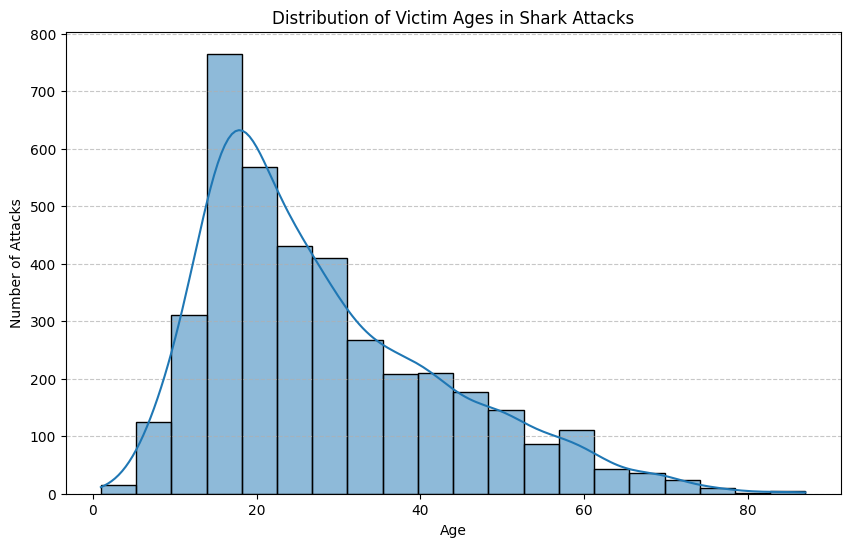

In [ ]:
# Clean the 'Age' variable
# Check the data type and unique values of 'Age'
print('Unique values in original Age column (top 20):')
display(shark_attacks_df['Age'].value_counts(dropna=False).head(20))

print('\nData type of Age column:', shark_attacks_df['Age'].dtype)

# Convert 'Age' to numeric, coercing errors to NaN
# This will handle values like '?', 'teen', 'mid-30s', etc.
shark_attacks_df['Age_cleaned'] = pd.to_numeric(shark_attacks_df['Age'], errors='coerce')

# Drop rows where 'Age_cleaned' is NaN, as these cannot be used in a histogram
# Note: This will remove rows where age was unparseable or originally NaN.
print(f"\nNumber of rows before dropping NaN ages: {len(shark_attacks_df)}")
shark_attacks_df.dropna(subset=['Age_cleaned'], inplace=True)
print(f"Number of rows after dropping NaN ages: {len(shark_attacks_df)}")

# Convert to integer type for clarity, as age is typically an integer
shark_attacks_df['Age_cleaned'] = shark_attacks_df['Age_cleaned'].astype(int)

# Display basic statistics of the cleaned age
print('\nDescriptive statistics for Cleaned Age:')
display(shark_attacks_df['Age_cleaned'].describe())

# Make a histogram of the ages of the victims
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(shark_attacks_df['Age_cleaned'], bins=20, kde=True)
plt.title('Distribution of Victim Ages in Shark Attacks')
plt.xlabel('Age')
plt.ylabel('Number of Attacks')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Q2.5: Proportion of male victims

In [ ]:
# Clean the 'Sex' variable and calculate the proportion of male victims

# Check the unique values in the original 'Sex' column
print('Unique values in original Sex column:')
display(shark_attacks_df['Sex'].value_counts(dropna=False))

# Standardize the 'Sex' column to 'M' (Male), 'F' (Female), or NaN (Unknown/Missing)
# Convert to uppercase first for consistency
shark_attacks_df['Sex_cleaned'] = shark_attacks_df['Sex'].astype(str).str.upper()

# Map variations to 'M' or 'F'
# Assuming 'M' and 'F' are the primary categories
# and 'lli' (likely a typo for 'Male' or 'Female') and 'N' should be treated as NaN or investigated further if context allows.
# For this task, let's map non-standard values other than 'M' or 'F' (including 'NaN' string) to NaN for clarity.
shark_attacks_df['Sex_cleaned'] = shark_attacks_df['Sex_cleaned'].replace({
    'M': 'Male',
    'F': 'Female',
    'N': 'Unknown',
    'NAN': 'Unknown',
    ' ' : 'Unknown', # Handle cases where sex might be a space
    'LLI': 'Unknown' # Based on observed unique values, treating 'lli' as unknown
})

# For simplicity, let's assume if it's not 'Male' or 'Female', it's unknown/not specified.
# Re-evaluating based on direct mapping of NaN to 'Unknown' and keeping only Male/Female for proportion.
# A common approach is to only count 'M' and 'F' for proportion and treat others as non-specified/missing.

# Let's refine the cleaning: only keep 'M' and 'F' and treat all others as NaN for calculation purposes.
shark_attacks_df['Sex_cleaned_for_proportion'] = shark_attacks_df['Sex'].astype(str).str.upper().replace({
    'M': 'M',
    'F': 'F'
})
# Set anything not 'M' or 'F' to NaN
shark_attacks_df['Sex_cleaned_for_proportion'] = shark_attacks_df['Sex_cleaned_for_proportion'].apply(lambda x: x if x in ['M', 'F'] else None)

print('\nUnique values in cleaned Sex column for proportion calculation:')
display(shark_attacks_df['Sex_cleaned_for_proportion'].value_counts(dropna=False))

# Calculate the proportion of male victims
male_count = (shark_attacks_df['Sex_cleaned_for_proportion'] == 'M').sum()
total_gender_specified = shark_attacks_df['Sex_cleaned_for_proportion'].count() # counts non-NaN values

if total_gender_specified > 0:
    proportion_male = male_count / total_gender_specified
    print(f"\nProportion of victims who are male (based on specified gender): {proportion_male:.2%}")
else:
    print("\nNo specified gender data to calculate the proportion of male victims.")

Unique values in original Sex column:


,count
Sex,
M,3324
F,582
NaN,33
M,3
F,2
M,1
m,1
lli,1



Unique values in cleaned Sex column for proportion calculation:


,count
Sex_cleaned_for_proportion,
M,3325
F,582
None,40



Proportion of victims who are male (based on specified gender): 85.10%


### Q2.6: Cleaning the 'Type' variable and proportion of unprovoked attacks

In [ ]:
# Clean the 'Type' variable to have three values: Provoked, Unprovoked, and Unknown

# Check the unique values in the original 'Type' column
print('Unique values in original Type column:')
display(shark_attacks_df['Type'].value_counts(dropna=False))

# Standardize the 'Type' column
# Convert to uppercase first for consistency and replace NaN with 'Unknown'
shark_attacks_df['Type_cleaned'] = shark_attacks_df['Type'].astype(str).str.upper()

# Define a mapping function to categorize types
def categorize_attack_type(attack_type):
    if 'UNPROVOKED' in attack_type:
        return 'Unprovoked'
    elif 'PROVOKED' in attack_type:
        return 'Provoked'
    else:
        return 'Unknown'

shark_attacks_df['Type_cleaned'] = shark_attacks_df['Type_cleaned'].apply(categorize_attack_type)

# Verify the cleaning by checking unique values and counts
print('\nUnique values in cleaned Type column:')
display(shark_attacks_df['Type_cleaned'].value_counts(dropna=False))

# Calculate the proportion of unprovoked attacks
unprovoked_count = (shark_attacks_df['Type_cleaned'] == 'Unprovoked').sum()
total_attacks_classified = len(shark_attacks_df) - (shark_attacks_df['Type_cleaned'] == 'Unknown').sum() # Count Provoked and Unprovoked

if total_attacks_classified > 0:
    proportion_unprovoked = unprovoked_count / total_attacks_classified
    print(f"\nProportion of attacks that are unprovoked (excluding unknown types): {proportion_unprovoked:.2%}")
else:
    print("\nNo classified attack types to calculate the proportion of unprovoked attacks.")

Unique values in original Type column:


,count
Type,
Unprovoked,3288
Provoked,313
Invalid,229
Watercraft,44
Sea Disaster,41
Questionable,19
NaN,10
unprovoked,1
?,1



Unique values in cleaned Type column:


,count
Type_cleaned,
Unprovoked,3289
Unknown,345
Provoked,313



Proportion of attacks that are unprovoked (excluding unknown types): 91.31%
